# Projet Calcul Quantique -  M2 IMPA et IMPC
## Application de la QFT
### Objectif général : Étudier la Transformée de Fourier Quantique (QFT) et ses applications à la recherche de période et à l’analyse fréquentielle.
Le projet comporte trois exercices de difficulté comparable mais qu'il vaut mieux aborder dans l'ordre proposé.

Lors de la soutenance orale les membres du trio peuvent être interrogés sur tous les exercices.

Le travail demandé inclut l'écriture de scripts python permettant d'interpréter les sorties de la librarie myQLM, soit avec des $print$ soit avec des $plot$ et montrant clairement que la simulation répond à la question posée.

N'hésitez pas à poser des questions sur le forum https://moodle-sciences-25.sorbonne-universite.fr/mod/forum/view.php?id=107663
si quelque chose n'est pas clair.

In [ ]:
!pip install myqlm

In [ ]:
!python -m qat.magics.install

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/qat/magics/install.py", line 25, in <module>
    install_qlm_magics()
  File "qat/core/magic/install.py", line 72, in qat.core.magic.install.install_qlm_magics
FileExistsError: Cannot install QLM magics bacause an IPython configuration is already defined. Please remove your IPython configuration to install QLM magics. The IPython config file is /root/.ipython/profile_default/startup/myqlm.py


La "Quantum Fourier Transform" (QFT) est l’équivalent quantique de la transformée de Fourier discrète (DFT).  
Pour un registre de $n$ qubits, elle agit sur les états de base $\{|0\rangle, \dots, |2^n-1\rangle\}$ comme :
$$
|x\rangle \xrightarrow{\text{QFT}} \frac{1}{\sqrt{2^n}} \sum_{y=0}^{2^n-1} e^{2i\pi xy/2^n} |y\rangle
$$
La QFT est implémentée à l’aide de portes de Hadamard et de rotations conditionnelles $R_k = \begin{pmatrix}1 & 0 \\ 0 & e^{2i\pi/2^k}\end{pmatrix}$ (portes PH avec myqlm)


# EXO 1.  Analyse d'un petit signal classique avec la QFT

##  Objectif

L’idée est de **simuler la Transformée de Fourier classique (FFT) dans un circuit quantique** :  

- On prend un petit **signal classique** (suite de nombres, par exemple `[1, 0, 2, 0]`)  
- On l’encode dans l’état d’un **registre quantique**  
- Puis on applique la **QFT** pour observer ses **composantes fréquentielles**, comme dans une FFT classique.



In [ ]:
# Récupérez les implémentations de la QFT étudiées dans le TP2
from qat.lang.AQASM import QRoutine, Program, PH, H,X,CNOT, SWAP
import math
####qf
# Séquentiel
####
def QFT_s(n):
    qft_routine = QRoutine()
    wires = qft_routine.new_wires(n)
    for i in range(n):
        qft_routine.apply(H,wires[n-i-1])
        for k in range(i+1,n):
            angle = math.pi / 2**(k-i)
            qft_routine.apply(PH(angle).ctrl(), wires[n-i-1] , wires[n-k-1])
    for i in range(n // 2):
        qft_routine.apply(SWAP, wires[i], wires[n - 1 -i])
    return qft_routine

####
# Récursive
####
def QFT_r(n):
    qft_routine = QRoutine()
    wires = qft_routine.new_wires(n)

    def qft_rec(sub_wires):
        m = len(sub_wires)

        if m == 1:
            qft_routine.apply(H, sub_wires[0])
            return

        qft_routine.apply(H, sub_wires[-1])

        for k in reversed(range(m - 1)):
            angle = math.pi / (2 ** (m - k - 1))
            qft_routine.apply(PH(angle).ctrl(),sub_wires[-1],sub_wires[k])
        qft_rec(sub_wires[:-1])

    qft_rec(wires)
    for i in range(n // 2):
        qft_routine.apply(SWAP, wires[i], wires[n - 1 - i])

    return qft_routine


In [ ]:

# Test QFT_s sur 5 qubits (séquentielle)
LL=5
prog = Program()
rout_qft_LL = QFT_s(LL)
reg = prog.qalloc(LL)
prog.apply(rout_qft_LL, reg)
prog.to_circ().display()

In [ ]:
# Test QFT_r sur 5 qubits (récursive)
LL=5
prog = Program()
rout_qft_LL = QFT_r(LL)
reg = prog.qalloc(LL)
prog.apply(rout_qft_LL, reg)
prog.to_circ().display()

On observe le même résultat pour la partie séquentielle et récursive. C'est le résultat attendu qui a été vu en cours.

### 1.1 Programmer l'encodage d'un signal classique en quantique
voir document state\_encoding.pdf


In [ ]:
#################################
### : encodage 2 qubits (2**2)###
#################################

from qat.lang.AQASM import RY
from math import acos, sqrt

def encode_amplitudes(amplitudes):
    """
    Transforme un signal classique normalisé de 4 valeurs contenues
    dans amplitudes en un signal quantique contenu dans qubits.
    """
    ea_routine = QRoutine()
    wires = ea_routine.new_wires(2)

    # le circuit d'encodage ici

    # Normalisation
    # Un état quantique représente des probabilités. La somme des probabilités doit faire 1.
    # Si on ne normalises pas, ce n'est pas un état quantique valide.
    norm = sqrt(sum(a**2 for a in amplitudes))
    if norm != 1:
      amplitudes = [a/norm for a in amplitudes]
    else:
      amplitudes = amplitudes

    # Récupération des valeurs
    a0 = amplitudes[0]
    a1 = amplitudes[1]
    a2 = amplitudes[2]
    a3 = amplitudes[3]

    # Calcul des angles theta
    theta1 = 2*acos(sqrt(a0**2 + a1**2))

    if a0**2 + a1**2 != 0:
      theta1_0 = 2*acos(a0/sqrt(a0**2 + a1**2))
    else:
      theta1_0 = 0
    if a2**2 + a3**2 != 0:
      theta1_1 = 2*acos(a2/sqrt(a2**2 + a3**2))
    else:
      theta1_1 = 0

    print("theta1  = ", theta1)
    print("theta1_0 = ", theta1_0)
    print("theta1_1 = ", theta1_1)

    # Encodage
    # Les valeurs du signal deviennent les coefficients devant les états de base/initiaux.
    ea_routine.apply(RY(theta1), wires[1])

    ea_routine.apply(RY(theta1_1).ctrl(), wires[1], wires[0])

    ea_routine.apply(X, wires[1])
    ea_routine.apply(RY(theta1_0).ctrl(), wires[1], wires[0])
    ea_routine.apply(X, wires[1])

    return ea_routine

# Tests:
signal = [1, 7, 2, 9]

# Normalisation
norm_sqrt = math.sqrt(1**2 + 7**2 + 2**2 + 9**2)
normalized_signal = [1/norm_sqrt, 7/norm_sqrt, 2/norm_sqrt, 9/ norm_sqrt]
print(f"Signal original: {signal}")
print(f"Signal normalisé: {normalized_signal}")
print(f"Vérification normalisation: {sum(a**2 for a in normalized_signal):.6f}")

encode_circuit = encode_amplitudes(signal)

print("\nCircuit d'encodage généré:")
from qat.lang.AQASM import Program
prog = Program()
qubits = prog.qalloc(2)
prog.apply(encode_circuit, qubits)
circuit = prog.to_circ()
circuit.display()


Signal original: [1, 7, 2, 9]
Signal normalisé: [0.08606629658238704, 0.6024640760767093, 0.17213259316477408, 0.7745966692414834]
Vérification normalisation: 1.000000
theta1  =  1.8330514856707532
theta1_0 =  2.8577985443814655
theta1_1 =  2.7042547618419093

Circuit d'encodage généré:


Généralisation au cas d'un signal de longueur $2^n$ avec $n$ quelconque, en programmant une version  par récurrence de encode\_amplitudes(n,amplitudes) avec $n$ quelconque.


In [ ]:
#################################
### : encodage généralisé à 2**n
#################################
import math
import numpy as np
from qat.lang.AQASM import QRoutine, RY, X, Program

def encode_amplitudes_recursive(amplitudes):
    # Transformation de la liste d'amplitudes en tableau numpy pour pouvoir faire des calculs vectoriels
    amplitudes = np.array(amplitudes, dtype=float)

    # Calcul de la norme du vecteur pour la normalisation
    norm = np.linalg.norm(amplitudes)

    # Si la norme est nulle (vecteur tout en 0)
    if norm == 0:
        raise ValueError("Erreur : le vecteur d'amplitudes est nul.")
    else:
        # Sinon on normalise simplement le vecteur
        amplitudes = amplitudes / norm

    # On calcule le nombre de qubits nécessaires pour encoder le vecteur
    n = int(math.log2(len(amplitudes)))

    # Fonction récursive interne pour encoder les amplitudes
    def encode_sub(amp, n_qubits):
        # Création d'une routine quantique
        routine = QRoutine()
        # On crée n_qubits fils (wires)
        wires = routine.new_wires(n_qubits)

        # On prend le dernier qubit comme qubit de contrôle
        msb = wires[-1] # msb : représente le qubit le plus significatif

        # CAS 1: seulement 1 qubit
        if n_qubits == 1:
            # Pour un seul qubit, on applique une rotation Y pour obtenir l'amplitude voulue
            theta = 2 * math.acos(amp[0])
            routine.apply(RY(theta), msb)
            return routine

        # CAS 2: 2 qubits
        if n_qubits == 2:
            return encode_amplitudes(amp) # déjà fait plus haut

        # CAS GENERAL : plus de 2 qubits
        # On divise le vecteur en deux moitiés
        half = len(amp) // 2
        left = amp[:half]
        right = amp[half:]
        norm_total = np.linalg.norm(amp)
        norm_left = np.linalg.norm(left)
        norm_right = np.linalg.norm(right)

        # Rotation pour le qubit le plus significatif afin de préparer l'état superposé entre gauche et droite
        theta = 2 * math.acos(norm_left / norm_total) if norm_total > 0 else 0
        routine.apply(RY(theta), msb)

        # Sous-circuit gauche
        if norm_left > 0:
            # On normalise la moitié gauche
            left_norm = left / norm_left
            # Appel récursif pour encoder cette moitié
            left_routine = encode_sub(left_norm, n_qubits - 1)
            # On applique le sous-circuit gauche de manière contrôlée par le qubit le plus significatif
            routine.apply(left_routine.ctrl(), msb, wires[:-1])

        # Sous-circuit droit
        if norm_right > 0:
            # Normalisation de la moitié droite
            right_norm = right / norm_right
            # Appel récursif pour encoder cette moitié
            right_routine = encode_sub(right_norm, n_qubits - 1)
            # Application contrôlée sur le qubit le plus signficatif après inversion avec  X
            routine.apply(X, msb)
            routine.apply(right_routine.ctrl(), msb, wires[:-1])
            routine.apply(X, msb)

        return routine
    return encode_sub(amplitudes, n)



### 1.2 Script principal

<UL>
    <LI>Choisissez un signal classique de taille $2^n$.
<LI>Encodez ce signal dans un registre de $n$ qubits (amplitudes proportionnelles aux valeurs du signal).
<LI>Appliquez la QFT.
<LI>Mesurez les probabilités des états de sortie.
<LI> Comparez le spectre obtenu à celui de la FFT classique. Utiliser pour cela le package numpy.fft, en faisant attention à la normalisation dans la définition de cette fft.
</UL>


Circuit pour: [1, 2, 3, 4]  :

theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032242



Circuit pour: [1, 2, 3, 4,1, 2, 3, 4]  :

theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032242
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032242



Circuit pour:[1, 2, 3, 4,1, 2, 3, 4, 1, 2, 3, 4,1, 2, 3, 4] :

theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246



Circuit pour: signal exponentiel

theta1  =  1.047197551196597
theta1_0 =  1.230959417340775
theta1_1 =  3.141592653589793
theta1  =  1.047197551196597
theta1_0 =  5.0522258898388115
theta1_1 =  3.1415926535897936




==Comparaison FFT et QFT==

theta1  =  1.6005036664825492
theta1_0 =  0.0
theta1_1 =  1.176005207095135

 Norme de l'erreur =  0.5628780357842333

Signal initial : [7. 0. 6. 4.]

Signal normalisé : [0.69652603 0.         0.59702231 0.39801488]

--- QFT ---
|00> : 0.8457816116784905+0.0000000000000000j
|01> : 0.0497518595104995-0.1990074380419977j
|10> : 0.4477667355944951+0.0000000000000000j
|11> : 0.0497518595104995+0.1990074380419977j

--- FFT  ---
k=0 (binaire 00) : 0.8457816116784908+0.0000000000000000j
k=1 (binaire 01) : 0.0497518595104995+0.1990074380419978j
k=2 (binaire 10) : 0.4477667355944951+0.0000000000000000j
k=3 (binaire 11) : 0.0497518595104995-0.1990074380419978j

En comparant avec la FFT, on peut constater que les résultats sont conjugués l’un de l’autre.
Cela provient du signe de l’exponentielle dans les formules :
- La FFT importée utilise par défaut un signe négatif dans l’exponentielle.
- Notre QFT est basée sur un signe positif.
Ainsi, malgré cette différence de 

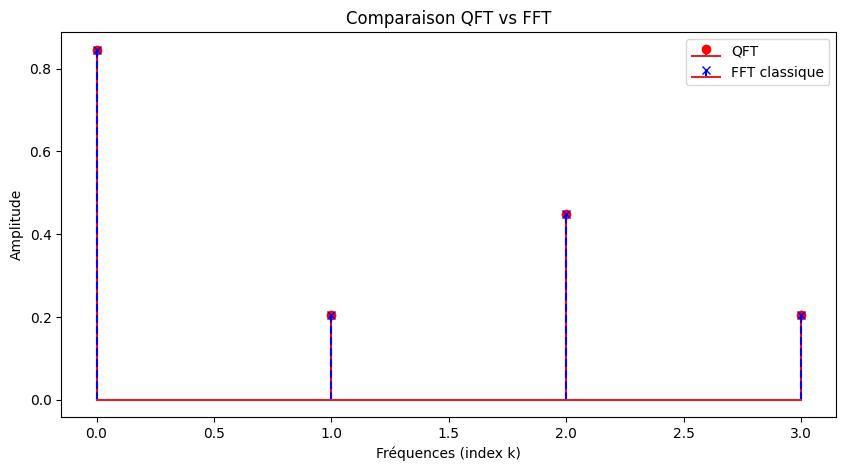

Erreur relative (à la fft) pour chaque fréquence : [2.62531843e-16 1.94028500e+00 0.00000000e+00 1.94028500e+00]
Erreur relative (à la qft) pour chaque fréquence : [2.62531843e-16 1.94028500e+00 0.00000000e+00 1.94028500e+00]
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032242
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032242

 Norme de l'erreur =  0.5163977794943222

Signal initial : [1. 2. 3. 4. 1. 2. 3. 4.]

Signal normalisé : [0.12909944 0.25819889 0.38729833 0.51639778 0.12909944 0.25819889
 0.38729833 0.51639778]

--- QFT ---
|000> : 0.9128709291752768+0.0000000000000000j
|001> : 0.0000000000000000+0.0000000000000000j
|010> : -0.1825741858350554-0.1825741858350554j
|011> : 0.0000000000000000+0.0000000000000000j
|100> : -0.1825741858350552+0.0000000000000000j
|101> : 0.0000000000000000+0.0000000000000000j
|110> : -0.1825741858350554+0.1825741858350554j
|111> : 0.0000000000000000+0.0000000000000000j

--- 

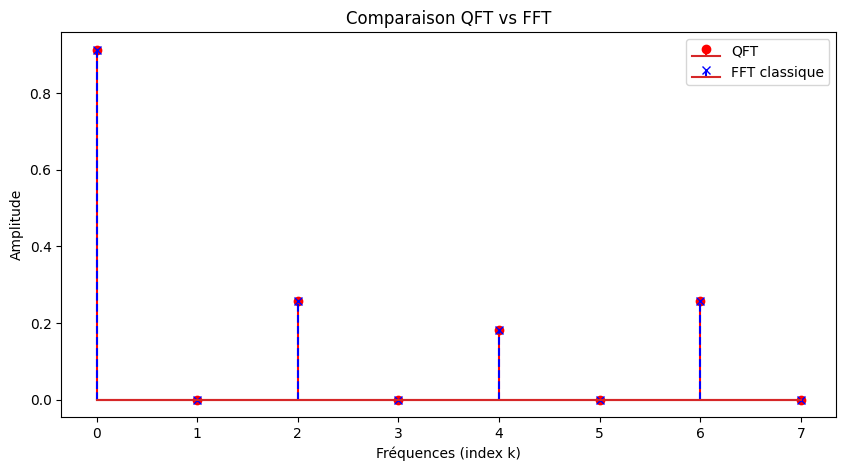

Erreur relative (à la fft) pour chaque fréquence : [2.43237678e-16 0.00000000e+00 1.41421356e+00 0.00000000e+00
 7.60117743e-16 0.00000000e+00 1.41421356e+00 0.00000000e+00]
Erreur relative (à la qft) pour chaque fréquence : [2.43237678e-16 0.00000000e+00 1.41421356e+00 0.00000000e+00
 7.60117743e-16 0.00000000e+00 1.41421356e+00 0.00000000e+00]
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246
theta1  =  2.300523983021863
theta1_0 =  2.214297435588181
theta1_1 =  1.8545904360032246

 Norme de l'erreur =  0.5163977794943223

Signal initial : [1. 2. 3. 4. 1. 2. 3. 4. 1. 2. 3. 4. 1. 2. 3. 4.]

Signal normalisé : [0.09128709 0.18257419 0.27386128 0.36514837 0.09128709 0.18257419
 0.27386128 0.36514837 0.09128709 0.18257419 0.27386128 0.36514837
 0.09128709 0.18257419 0.273

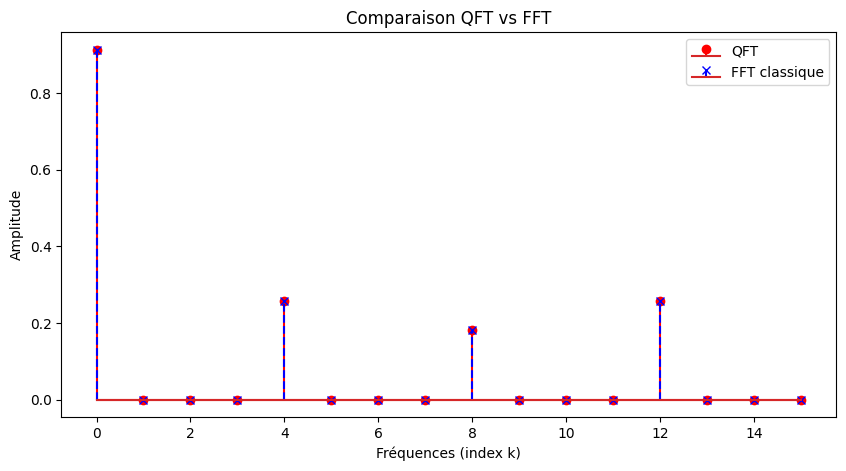

Erreur relative (à la fft) pour chaque fréquence : [2.43237678e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.41421356e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.04047097e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.41421356e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Erreur relative (à la qft) pour chaque fréquence : [2.43237678e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.41421356e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.04047097e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.41421356e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [ ]:
#######TESTS

from qat.qpus import PyLinalg
import matplotlib.pyplot as plt

# Affichage du circuit sous plusieurs signaux
print("\n=============================")
print("Circuit pour: [1, 2, 3, 4]  :")
print("\n=============================")
amplitudes1 = [1, 2, 3, 4]  # longueur 2^2 = 4
n_qubits = int(math.log2(len(amplitudes1)))
prog = Program()
reg = prog.qalloc(n_qubits)
rout = encode_amplitudes_recursive(amplitudes1)
prog.apply(rout, reg)
prog.to_circ().display()

print("\n========================================")
print("Circuit pour: [1, 2, 3, 4,1, 2, 3, 4]  :")
print("\n========================================")
amplitudes2 = [1, 2, 3, 4,1, 2, 3, 4]  # longueur 2^3 = 8
n_qubits = int(math.log2(len(amplitudes2)))
prog = Program()
reg = prog.qalloc(n_qubits)
rout = encode_amplitudes_recursive(amplitudes2)
prog.apply(rout, reg)
prog.to_circ().display()

print("\n============================================================")
print("Circuit pour:[1, 2, 3, 4,1, 2, 3, 4, 1, 2, 3, 4,1, 2, 3, 4] :")
print("\n============================================================")
amplitudes3 = [1, 2, 3, 4,1, 2, 3, 4, 1, 2, 3, 4,1, 2, 3, 4]  # longueur 2^4 = 16
n_qubits = int(math.log2(len(amplitudes3)))
prog = Program()
reg = prog.qalloc(n_qubits)
rout = encode_amplitudes_recursive(amplitudes3)
prog.apply(rout, reg)
prog.to_circ().display()

print("\n================================")
print("Circuit pour: signal exponentiel")
print("\n================================")
N = 8  # longueur du signal, doit être une puissance de 2
f = 1  # fréquence (en cycles sur N échantillons)
t = np.arange(N)
amplitudes4 = np.exp(2j * np.pi * f * t / N)
n_qubits = int(math.log2(len(amplitudes4)))
prog = Program()
reg = prog.qalloc(n_qubits)
rout = encode_amplitudes_recursive(amplitudes4)
prog.apply(rout, reg)
prog.to_circ().display()

#Une fonction pour tester le signal
print("\n==========================")
print("\n==Comparaison FFT et QFT==")
print("\n==========================")
def test_signal(signal):

    signal = np.array(signal, dtype=float)
    N = len(signal)
    n_qubits = int(math.log2(N))

    signal_norm = signal / np.linalg.norm(signal)

    prog = Program()
    qreg = prog.qalloc(n_qubits)

    prog.apply(encode_amplitudes_recursive(signal_norm), qreg)
    prog.apply(QFT_r(n_qubits), qreg)

    circ = prog.to_circ()
    qpu = PyLinalg()
    result = qpu.submit(circ.to_job())

    qft_amp = np.zeros(N, dtype=complex)

    for sample in result:
        i = sample.state.int
        qft_amp[i] = sample.amplitude


    fft_classique = np.fft.fft(signal_norm) / np.sqrt(N)
    #fft_classique = np.fft.fftshift(fft_classique)
    # Ici on réordonne l'ordre d'affichage car par défaut l'ordre d'indexation de FFT n'est pas le même que celle qu'on obtient.
    # La QFT renvoie les amplitudes dans un ordre bit-reversé par rapport à la FFT classique.
    # Afin de comparer numériquement les deux transformations, nous réordonnons les indices.
    qft_reordered = np.zeros_like(qft_amp)
    for i in range(N):
        natural_idx = int(f"{i:0{n_qubits}b}"[::-1], 2)
        qft_reordered[i] = qft_amp[natural_idx]

    print("\n Norme de l'erreur = ",
          np.linalg.norm(qft_reordered - fft_classique))

    print("\n==============================")
    print("Signal initial :", signal)

    print("\n==============================")
    print("Signal normalisé :", signal_norm)

    print("\n--- QFT ---")
    for i, a in enumerate(qft_reordered):
        print(f"|{i:0{n_qubits}b}> : {a:.16f}")


    print("\n--- FFT  ---")
    for i, a in enumerate(fft_classique):
        print(f"k={i} (binaire {i:0{n_qubits}b}) : {a:.16f}")
    print("\nEn comparant avec la FFT, on peut constater que les résultats sont conjugués l’un de l’autre.")
    print("Cela provient du signe de l’exponentielle dans les formules :")
    print("- La FFT importée utilise par défaut un signe négatif dans l’exponentielle.")
    print("- Notre QFT est basée sur un signe positif.")
    print("Ainsi, malgré cette différence de signe, on a bien résultats équivalents.\n")
    print("En les ramenant tous les deux aux mêmes signes on obtient exactement la même chose.\n")

    print("\nErreur ||QFT - FFT|| =", np.linalg.norm(qft_reordered - fft_classique))


    plt.figure(figsize=(10,5))
    plt.stem(np.arange(N), np.abs(qft_reordered), linefmt='r-', markerfmt='ro', label='QFT')
    plt.stem(np.arange(N), np.abs(fft_classique), linefmt='b--', markerfmt='bx', label='FFT classique')
    plt.xlabel("Fréquences (index k)")
    plt.ylabel("Amplitude")
    plt.title("Comparaison QFT vs FFT")
    plt.legend()
    plt.show()

    # Erreurs entre FFT et QFT
    erreur_relative1 = np.abs(qft_reordered - fft_classique) / (np.abs(fft_classique) + 1e-12) #1e-12 sert à éviter une division par 0
    print("Erreur relative (à la fft) pour chaque fréquence :", erreur_relative1)
    erreur_relative2 = np.abs(qft_reordered - fft_classique) / (np.abs(qft_reordered) + 1e-12)
    print("Erreur relative (à la qft) pour chaque fréquence :", erreur_relative2)

####
signal1 = [7, 0, 6, 4]
signal2 = [1, 2, 3, 4, 1, 2, 3, 4]
signal3 = [1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]

test_signal(signal1)
test_signal(signal2)
test_signal(signal3)

Le code ci-dessus doit présenter les résultats et les conclusions de manière compréhensible. Ne vous contentez pas des sorties brutes de myqlm. Vous devez les transformer avec du code Python.

 <li>Comparez les amplitudes finales avec celles de $numpy.fft.fft(signal)$.
 <li>Quelle est la signification physique des pics obtenus ?
<li>Pourquoi la QFT est-elle plus efficace que la FFT classique en théorie ?


1. Les positions des pics sont identiques. Les amplitudes de la QFT sont simplement une version "réduite" et normalisée des amplitudes classiques.
2. Un pic à l'indice $k$ signifie que le signal d'origine contient une composante périodique oscillant à la fréquence correspondante.
3. La QFT est plus efficace en nombre d'opérations nécessaires pour un signal de taille $N = 2^n$. La FFT donne une croissance exponentielle par rapport au nombre de qubits. En QFT, si on ajoute 1 qubit, on ajoute seulement quelques portes quantiques supplémentaires.

# EXO 2 - Recherche de période (version simplifiée de l’algorithme de Shor)
## Objectif:
Mettre en œuvre la QFT pour déterminer la période d’une fonction périodique discrète.  

On considère une fonction périodique $f : \mathbb{Z}_{2^n} \to \mathbb{Z}_{2^n}$ de période $r$.  
L’idée est :
<ul>  <li>Préparer une superposition uniforme de tous les états $|x\rangle$.</li>
<li> Calculer $f(x)$ sur un second registre.</li>
<li> Appliquer la QFT sur le premier registre.</li>
<li> Mesurer et en déduire la période $r$.</li>
</ul>



## 2.1 Implémentez une fonction périodique simple
par exemple :
 $$
  f(x) = (a^x \bmod N)
$$
  avec de petits paramètres ($a=3$, $N=7$).  
  Vous pouvez simuler $f$ classiquement dans MyQLM pour trouver $r$ "à la main".


**Exemple avec 15 (N=15) et on choisit a=7 :**

- $7^1 = 7$
- $7^2 = 49$ Et 49 modulo 15, ça fait **4** (car $15 \times 3 = 45$, il reste 4).
- $7^3 = 343$. Modulo 15, ça fait **13**.
- $7^4 = ...$ Modulo 15, ça fait **1**.
- $7^5 = ...$ Modulo 15, ça retombe sur **7**.

La suite est : 7, 4, 13, 1, 7, 4, 13, 1...
La période est de 4 (il y a 4 nombres avant que ça recommence).

In [ ]:
def f(x, a=3, N=7):
    return pow(a,x,N)

# Tester $f$ pour calculer r à la main

print("x | f(x)")
print("-------")
for x in range(10):  # On teste les 10 premières valeurs
    val = f(x)
    print(f"{x} | {val}")

# Détermination automatique
def find_period(a=3, N=7, max_x=20):
    values = []
    for x in range(1, max_x):
        y = f(x, a, N)
        values.append(y)
        #print(f"x = {x}, f(x) = {y}")
        if y == 1:
          return x
    return None
resultat = find_period()
print("\n")
print("Période trouvée:", resultat)



x | f(x)
-------
0 | 1
1 | 3
2 | 2
3 | 6
4 | 4
5 | 5
6 | 1
7 | 3
8 | 2
9 | 6


Période trouvée: 6


## 2.2 Fonction oracle quantique
<ul>        <li> Implémentez une fonction "oracle_f" appliquant $|x\rangle|0\rangle \mapsto |x\rangle|f(x)\rangle$.
</li>
    </ul>


**Explication** :

Imaginons que l'on veuille calculer $a^{13}$.

En binaire, $13$ s'écrit 1101.

Ce qui veut dire : $13 = 8 + 4 + 0 + 1$.
Donc mathématiquement : $a^{13} = a^8 * a^4 * a^1$

Au lieu de calculer une puissance compliquée, le circuit va simplement faire une série de multiplications élémentaires.

Le Registre de Contrôle ($x$) : le nombre 13 (1101).

Le Registre Cible (Target) : commence à la valeur 1 et va subir les multiplications.

Le premier qubit de contrôle active la multiplication par $a^1$, le deuxième par $a^2$, le troisième par $a^4$, et ainsi de suite (les puissances de 2).

Au lieu de calculer une puissance complexe, on accumule simplement des multiplications partielles selon que les bits de $x$ valent 0 ou 1.

In [ ]:
#2.2
from qat.lang.AQASM import Program, H, X
from qat.qpus import get_default_qpu

def f(x, a=3, N=7):
    """
    Calcule l'exponentiation modulaire
    """
    return pow(a,x,N)

def oracle_f(prog, qbits_x, qbits_fx, a=3, N=7):
    """
    Implémente |x>|y> -> |x>|y xor f(x)>, avec f(x) = a^x mod N.
    prog  : objet Program() de MyQLM (on lui applique des gates)
    qbits_x : liste/iterable de qubits du registre x (n qubits) -> Registre d'entrée (contient la valeur x).
    qbits_fx: liste/iterable des qubits du registre f(x) (m qubits) -> Registre de sortie (recevra le résultat f(x)).
    """

    n_x = len(qbits_x)
    n_fx = len(qbits_fx)

    for x_val in range(2**n_x):
        x_bin_str = format(x_val, f'0{n_x}b') # conversion en binaire

        target_val = f(x_val, a, N)

        target_bin_str = format(target_val, f'0{n_fx}b')

        for i, bit in enumerate(x_bin_str):
          if bit == '0': # si le bit de notre valeur actuelle x est 0 on le transforme temporairement en 1 pour le contrôle
            prog.apply(X,qbits_x[i])
          # résultat : le registre qubit_x ne sera dans l'état |11..1> que si sa valeur d'origine était x_val

        # écriture du résultat
        # si le registre x correspond à notre valeur cible, on écrit f(x) dans le registre de sortie
        for i, bit_target in enumerate(target_bin_str):
          if bit_target == '1':
            prog.apply(X.ctrl(n_x),list(qbits_x) + [qbits_fx[i]])

        for i in range(n_x): # réappliquer les portes X sur le registre x pour remettre les qubits dans son état initial
            if x_bin_str[i] == '0':
                prog.apply(X, qbits_x[i])
    return

# Test syntaxique  de l'oracle
def test_syntaxique():
    """
    Vérifie que l'oracle s'exécute sans erreur.
    Ne teste pas la correction mathématique.
    """
    print("Test syntaxique")

    # Création programme quantique simple
    prog = Program()
    n_x = 3
    n_fx = 3
    qbits_x = prog.qalloc(n_x)
    qbits_fx = prog.qalloc(n_fx)

    # Appel de l'oracle
    try:
        oracle_f(prog, qbits_x, qbits_fx, a=3, N=7)
        circuit = prog.to_circ()
        print("L'oracle s'exécute sans erreur")
        print("Le circuit est créé correctement")
        print(f"Nombre de portes dans le circuit: {len(circuit.ops)}")
        return True
    except Exception as e:
        print(f"Erreur: {e}")
        return False

# Test systématique de l'oracle
def test_systematique():
  """
  Vérifie que |x>|0> -> |x>|f(x)> pour toutes les valeurs de x.
  Teste la correction mathématique de l'oracle.
  """
  print("\nTest systématique\n")

  n_x = 3
  n_fx = 3
  a, N = 3, 7
  qpu = get_default_qpu() # simulateur quantique
  all_correct = True

  for x_test in range(2**n_x):
      prog = Program()
      qbits_x = prog.qalloc(n_x)
      qbits_fx = prog.qalloc(n_fx)

      x_bin = format(x_test, f'0{n_x}b')
      for i, bit in enumerate(x_bin):
          if bit == '1':
              prog.apply(X, qbits_x[i])

      oracle_f(prog, qbits_x, qbits_fx, a = a, N = N)

      circuit = prog.to_circ()
      job = circuit.to_job()
      result = qpu.submit(job)

      # Vérification des résultats
      for sample in result:
          state_int = sample.state.int # conversion binaire à int
          # Extraire les parties x et f(x)
          x_part = state_int >> n_fx # bit shift pour conserver que x
          fx_part = state_int & ((1 << n_fx) - 1) # calcul du masque et addition pour conserver f(x)

          # Calcul du résultat attendu
          expected_fx = f(x_test, a, N)

          # Vérification
          if x_part == x_test and fx_part == expected_fx:
              print(f"x={x_test}: |{x_test}>|0> -> |{x_part}>|{fx_part}> (f({x_test})={expected_fx})")
          else:
              print(f"x={x_test}: ERREUR!")
              print(f"Attendu: |{x_test}>|{expected_fx}>")
              print(f"Obtenu:  |{x_part}>|{fx_part}>")
              tous_corrects = False

  if all_correct:
      print("\nTOUS LES TESTS SONT CORRECTS")
  else:
      print("\nCERTAINS TESTS ONT ÉCHOUÉ")

  return all_correct


Explication du shift:

L'opérateur >> (bit-shift) "pousse" les bits vers la droite et fait tomber ceux qui dépassent.

Si l'ordinateur quantique trouve l'état $|x=3\rangle |f(x)=6\rangle$, en binaire cela donne : 011 suivi de 110.

Le tout forme un seul nombre binaire : 011110 qui fait 30.

Si on décale de 3 vers la droite on a 011 qui fait 3.

```
#   011 110  (state_int)
# & 000 111  (le masque)
# ----------
#   000 110  (résultat)
```

In [ ]:
print("\nTESTS DE L'ORACLE QUANTIQUE\n")
syntaxe_ok = test_syntaxique()

if syntaxe_ok:
    systematique_ok = test_systematique()
else:
    print("\nTest systématique non exécuté (erreur syntaxique)")
print("\nFIN DES TESTS\n")



TESTS DE L'ORACLE QUANTIQUE

Test syntaxique
L'oracle s'exécute sans erreur
Le circuit est créé correctement
Nombre de portes dans le circuit: 36

Test systématique

x=0: |0>|0> -> |0>|1> (f(0)=1)
x=1: |1>|0> -> |1>|3> (f(1)=3)
x=2: |2>|0> -> |2>|2> (f(2)=2)
x=3: |3>|0> -> |3>|6> (f(3)=6)
x=4: |4>|0> -> |4>|4> (f(4)=4)
x=5: |5>|0> -> |5>|5> (f(5)=5)
x=6: |6>|0> -> |6>|1> (f(6)=1)
x=7: |7>|0> -> |7>|3> (f(7)=3)

TOUS LES TESTS SONT CORRECTS

FIN DES TESTS



## 2.3 Circuit quantique
Construisez le circuit suivant :
<ul>    <li> $n=3$ qubits pour le registre $x$,
   <li>$m=3$ qubits pour le registre $f(x)$.
<li>preparez une superposition uniforme sur le registre $x$</li>
    <li> Appliquez la fonction "oracle_f"  $|x\rangle|0\rangle \mapsto |x\rangle|f(x)\rangle$.
    <li> Mesurez les qbits contenant le registre $f(x)$  
    <li> Appliquez la QFT sur le 1er registre</li>
    <li> Mesurez les qbits et analysez les probabilités. En particulier écrire un code affichant la période $r$ trouvée.</li>
   </ul>

Vous devez être capable d'expliquer pourquoi cet algo fonctionne. C'est un cas particulier de l'algorithme  de SHOR.
   

**Pourquoi l'algorithme fonctionne ?**

L'algorithme fonctionne parce que la structure périodique créée par l'oracle permet à la QFT de générer des interférences constructives uniquement pour les multiples de la fréquence recherchée, et des interférences destructives pour toutes les autres valeurs, ne laissant survivre que la bonne réponse lors de la mesure.

Si on imagine que les "mauvaises réponses" (celles qui ne correspondent pas à la période) sont des vagues, la QFT fait en sorte qu'elles se rentrent dedans et s'annulent. A l'inverse, les "bonnes réponses" (celles qui correspondent à la période), les vagues se synchronisent, ce qui crée une vague géante.

En résumé, la QFT amplifie uniquement la fréquence qui correspond à la période du système et "tue" tout le reste.

In [ ]:
# Circuit quantique
from qat.lang.AQASM import Program, H, X
from qat.qpus import get_default_qpu
import numpy as np

a = 3
N = 7

n = 3 # qubits pour le registre x
m = 3 # qubits pour le registre f(x)
prog = Program()

qbits_x = prog.qalloc(n)  # Registre x (n qubits)
qbits_fx = prog.qalloc(m) # Registre f(x) (m qubits)

# Préparer une superposition uniforme sur le registre x
for qubit in qbits_x :
  prog.apply(H, qubit)

# Application la fonction oracle
oracle_f(prog, qbits_x, qbits_fx, a = a, N = N)

# Application de la QFT sur le 1er registre
# On transforme la périodicité temporelle en pic de probabilité
prog.apply(QFT_s(n), qbits_x)

circuit = prog.to_circ()
job = circuit.to_job(qubits=list(range(n))) # Mesure seulement les n premiers qubits (le registre x)
qpu = get_default_qpu()
result = qpu.submit(job)

measurements = {}
for sample in result:
    # Lire la valeur mesurée sur le registre x
    x_val = sample.state.int
    measurements[x_val] = measurements.get(x_val, 0) + sample.probability

print(f"\nRésultats des mesures pour f(x) = {a}^x mod {N}:\n")
print("Valeur | Probabilité | Ratio (valeur/2^n)")

for val in sorted(measurements.keys()):
    prob = measurements[val]
    ratio = val / (2**n)
    print(f"{val:6d} | {prob:11.4f} | {ratio:.4f}")

# Trouver la mesure la plus probable
most_likely_val = None
highest_prob = -1

for value, probability in measurements.items(): # .items() transforme le dictionnaire en liste de paires (clé, valeur)
    if probability > highest_prob:
        highest_prob = probability
        most_likely_val = value

print(f"\nValeur la plus probable: {most_likely_val}\n")

ratio = most_likely_val / (2**n)   # 0.5

print(f"Valeur = {most_likely_val}, ratio = {ratio:.3f}")

# Chercher la période r
found = False
for r in range(1, 2**n + 1):
    # Chercher k tel que k/r ≈ ratio
    for k in range(r):
        if abs(k/r - ratio) < 0.15:  # si proche
            # Vérifier si c'est une période
            if pow(a, r, N) == 1:
                print(f"Période trouvée: r = {r} car {a}^{r} mod {N} = 1")
                found = True
                break  # sort de la boucle k
    if found:
        break  # sort de la boucle r

if not found:
    print("Aucune période trouvée avec ce c")


Résultats des mesures pour f(x) = 3^x mod 7:

Valeur | Probabilité | Ratio (valeur/2^n)
     0 |      0.1875 | 0.0000
     1 |      0.0625 | 0.1250
     2 |      0.1250 | 0.2500
     3 |      0.1250 | 0.3750
     4 |      0.0808 | 0.5000
     5 |      0.1692 | 0.6250
     6 |      0.1692 | 0.7500
     7 |      0.0808 | 0.8750

Valeur la plus probable: 0

Valeur = 0, ratio = 0.000
Période trouvée: r = 6 car 3^6 mod 7 = 1


**Analyse des résultats** :

La valeur 0 est statistiquement la plus probable, mais c'est un cas trivial qui ne permet pas de trouver la période. En traitement du signal (et donc en QFT), la fréquence 0 correspond à la composante "continue" (la moyenne). Elle est toujours présente. Dans la pratique, on rejetterait ce résultat pour refaire une mesure.

Si on omet ce résultat, les valeurs les plus probables sont 5 et 6.

Pour avoir un résultat net, il faudrait augmenter le nombre de qubits ($n=6$ ou plus). Ainsi, les pics seraient beaucoup plus précis.

**Recheche de la période** :

Après la QFT, on mesure une valeur. On a la relation suivante $\frac{\text{Valeure mesurée }(y)}{\text{Taille du registre }(2^n)} = \frac{\text{Entier }(k)}{\text{Période }(r)}$

Donc si on mesure 4, ratio $= 4/8 = 0.5$

On cherche $k/r ~= 0.5$

Possibilités : $1/2, 2/4, 3/6...$. Donc r pourrait être $2, 4, 6...$

Dans notre cas :

**Taille du registre** : On a 3 qubits, donc $2^3 = 8$ positions possibles.

**Période réelle** : $r = 6$.



# EXO 3 Estimation de phase quantique (Quantum Phase Estimation, QPE)

## Objectif
Mettre en oeuvre l'estimation de phase quantique (QPE) afin de déterminer la phase d'un opérateur unitaire $U$ agissant sur un état propre $|\psi\rangle$ tel que :
$$
U |\psi\rangle = e^{2i\pi \phi} |\psi\rangle
$$
L'objectif est d'estimer la valeur de $\phi$ avec une précision déterminée par le nombre de qubits du registre de phase.

### Principe théorique
L'algorithme d'estimation de phase repose sur la QFT inverse appliquée à un registre de phase.  
On utilise deux registres :
<UL>
  <li>Un registre de phase de $n$ qubits, initialisé à $|0\rangle^{\otimes n}$.
  <LI>Un registre cible contenant l'état propre $|\psi\rangle$.
</UL>
Les étapes sont les suivantes :
<UL>
 <li>Créer une superposition uniforme sur le registre de phase :
 $$
  \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} |k\rangle |\psi\rangle
$$
 <li>Appliquer l'opérateur $U^{2^k}$ contrôlé par chaque qubit du registre de phase :
$$
  \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{2i\pi \phi k} |k\rangle |\psi\rangle
$$
  <li>Appliquer la QFT inverse sur le registre de phase.
  <li>Mesurer le registre de phase : le résultat correspond à une approximation binaire de la phase $\phi$.
</UL>

### Exemple concret
Prenons l'opérateur unitaire :
$$
U = R_z(2\pi \times 0.375) =
\begin{pmatrix}
1 & 0\\
0 & e^{2i\pi \times 0.375}
\end{pmatrix}
$$
et l'état propre $|\psi\rangle = |1\rangle$.  
On a alors $U|\psi\rangle = e^{2i\pi \times 0.375} |\psi\rangle$, donc $\phi = 0.375 = 3/8$.  
Si le registre de phase contient trois qubits, le résultat attendu est l'état $|011\rangle$.

**Note**

L'objectif est d'estimer la phase propre $\theta$ d'un opérateur unitaire $U$. C'est une valeur comprise entre 0 et 1 qui représente de combien l'état tourne sur lui-même.

## 3.1  QFT inverse

In [ ]:
# 3.1. Programmation et test de la QFT inverse
import math
from qat.lang.AQASM import QRoutine, Program, H, PH, SWAP, X
from qat.qpus import PyLinalg

def qft_inverse(n): # On commence par les SWAP, les rotations conditionnelles après et enfin la porte de Hadamard à la fin.
    qft_inv_routine = QRoutine()
    wires = qft_inv_routine.new_wires(n)
    for i in range(n // 2):
        qft_inv_routine.apply(SWAP, wires[i], wires[n - 1 - i])
    for i in reversed(range(n)): # reversed(range(n)) pour parcourir de n-1 à 0
        for k in reversed(range(i+1, n)):
            angle = -math.pi / 2**(k-i)
            qft_inv_routine.apply(PH(angle).ctrl(), wires[n-i-1], wires[n-k-1])
        qft_inv_routine.apply(H, wires[n-i-1])
    return qft_inv_routine


#Circuit de l'inverse

LL=4
prog = Program()
rout_qft_LL = qft_inverse(LL)
reg = prog.qalloc(LL)
prog.apply(rout_qft_LL, reg)
prog.to_circ().display()



In [ ]:
#TESTS
import numpy as np
from qat.qpus import get_default_qpu
qpu = get_default_qpu()

LL = 3
rout_qft_LL = QFT_s(LL)
rout_qft_inv_LL = qft_inverse(LL)

#ICI pour chaque état initial, on doit trouver le même état à la sortie(avec une probabilité égale à 1)
# Boucle sur la base computationnelle |j> = |j0 j1 j2>
for j2 in range(2):
    for j1 in range(2):
        for j0 in range(2):

            prog = Program()
            qj = prog.qalloc(LL)

            # Préparation de |j>
            if j0:
                prog.apply(X, qj[0])
            if j1:
                prog.apply(X, qj[1])
            if j2:
                prog.apply(X, qj[2])

            j = j2 * 4 + j1 * 2 + j0
            print("\n==============================================")
            print(f"Qubit d'entrée |{j2}{j1}{j0}> (j = {j})")

            # Vérification de l'état initial
            circ_ini = prog.to_circ()
            job_ini = circ_ini.to_job()
            result_ini = qpu.submit(job_ini)

            print("État initial mesuré :")
            for sample in result_ini:
                print(
                    f"  |{sample.state.bitstring}> " # sample.state.bitstring = état classique mesuré ∣bn−1​…b1​b0​⟩
                    f"probabilité = {sample.probability}"
                )

            # Application QFT puis QFT^{-1}
            prog.apply(rout_qft_LL, qj)
            prog.apply(rout_qft_inv_LL, qj)

            circ = prog.to_circ()
            job = circ.to_job()
            result = qpu.submit(job)

            print("État en sortie après QFT ∘ QFT^{-1} :")
            for sample in result:
                k0 = int(sample.state.bitstring[2])
                k1 = int(sample.state.bitstring[1])
                k2 = int(sample.state.bitstring[0])
                k = k0 * 4 + k1 * 2 + k2

                print(
                    f"  |{sample.state.bitstring}> "
                    f"probabilité = {sample.probability}"
                )
                print(f"  k = {k0}×4 + {k1}×2 + {k2} = {k}")

            # Test logique attendu
            print(
                "Résultat attendu : |{:03b}> avec probabilité approximativement : 1".format(j)
            )
print("\n ------------TESTS REUSSI POUR LA QFT INVERSE.------------- \n")


Qubit d'entrée |000> (j = 0)
État initial mesuré :
  |000> probabilité = 1.0
État en sortie après QFT ∘ QFT^{-1} :
  |000> probabilité = 0.9999999999999991
  k = 0×4 + 0×2 + 0 = 0
Résultat attendu : |000> avec probabilité approximativement : 1

Qubit d'entrée |001> (j = 1)
État initial mesuré :
  |100> probabilité = 1.0
État en sortie après QFT ∘ QFT^{-1} :
  |100> probabilité = 0.9999999999999991
  k = 0×4 + 0×2 + 1 = 1
Résultat attendu : |001> avec probabilité approximativement : 1

Qubit d'entrée |010> (j = 2)
État initial mesuré :
  |010> probabilité = 1.0
État en sortie après QFT ∘ QFT^{-1} :
  |010> probabilité = 0.9999999999999991
  k = 0×4 + 1×2 + 0 = 2
Résultat attendu : |010> avec probabilité approximativement : 1

Qubit d'entrée |011> (j = 3)
État initial mesuré :
  |110> probabilité = 1.0
État en sortie après QFT ∘ QFT^{-1} :
  |110> probabilité = 0.9999999999999991
  k = 0×4 + 1×2 + 1 = 3
Résultat attendu : |011> avec probabilité approximativement : 1

Qubit d'entrée |100

## 3.2 Script principal

In [ ]:
# 3.2 script principal
from qat.lang.AQASM import Program, H, PH,SWAP, X
from qat.qpus import get_default_qpu
import numpy as np
import math

# Nombre de qubits pour le registre de phase
n = 3
phi = 3/8
prog = Program()
q_phase = prog.qalloc(n)
q_target = prog.qalloc(1) # pour |psi>
# Considérons l'exemple où le |psi> = |1>
prog.apply(X, q_target[0])

for i in range(n):
  prog.apply(H, q_phase[i])

for k in range(n):
  angle = 2 * math.pi * phi * (2**k)
  prog.apply(PH(angle).ctrl(), q_phase[k], q_target[0])

prog.apply(qft_inverse(n), q_phase)

circ = prog.to_circ()
job = circ.to_job()
result = qpu.submit(job)
print("Résultat de la mesure: \n")
for sample in result:
  print(
      f"Etat mesuré : |{sample.state.bitstring[0:n][::-1] }> " # [0:n]: pour avoir les n sorties en rapport avec q_phase et [::-1]: pour inverser et afficher dans l'ordre normal
      f" , avec probabilté: {sample.probability}"
  )


Résultat de la mesure: 

Etat mesuré : |011>  , avec probabilté: 0.9999999999999991


**Analyse du résultat** :

On a mesuré $011$. Ce n'est pas 3 mais une fraction binaire (chaque bit correspond à une puissance négative de 2) qui se calcule comme ceci :

On additionne les contributions où il y a un "1"

$\theta = \frac{0}{2^1} + \frac{1}{2^2} + \frac{1}{2^3} = 0 + 0.25 + 0.125 = 0.375$

L'opérateur fait tourner l'état de $37.5\%$ d'un tour complet (135°).


## 3.3 Interprétation
- Si la phase ne peut pas s'écrire exactement sur $n$ bits, que se passe-t-il ?
- Pourquoi la QFT inverse permet-elle de "lire" la phase dans le registre ?
- Testez avec $\phi = 0.25$, $\phi = 0.625$ et $\phi = 0.1$. Comparez les distributions de mesure.
- Quelle est la précision de l'estimation en fonction du nombre de qubits $n$ ?
- Comparez la complexité théorique de la QPE à une estimation classique de phase.


Interprétation (Résultat):

---

*   Si la phase ne peut pas s'écrire exactement sur n bits alors l'algorithme produit une distribution de mesures centrée sur la meilleure approximation binaire de 𝜙. La précision peut être augmentée en ajoutant plus de qubits au registre de phase.
* Si la phase ne peut pas s'écrire exactement sur n bits et nécessite moins de bits que n alors l'algorithme affiche tous les bits en rapport avec la phase et complète des 0 jusqu'à atteindre les n bits(si n = 3 et phi = 0.25 par exemple).
*   La QFT inverse permet de transformer les phases dans les qubits en un état qu’on peut mesurer. Avant (avec ceci: $$
  \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{2i\pi \phi k} |k\rangle
$$), la phase est cachée dans les amplitudes, après elle devient visible dans le registre. Elle prend les amplitudes contenant des phases et les transforme pour que la probabilité de mesurer le registre soit concentrée sur le bitstring correspondant à
𝜙.



In [ ]:
#TESTS
# 3.2 script principal
from qat.lang.AQASM import Program, H, PH,SWAP, X
from qat.qpus import get_default_qpu
import numpy as np
import math

n = 3
phi_list = [0.25, 0.625, 0.1]  # valeurs de phi à tester


qpu = get_default_qpu()

for phi in phi_list:
    print(f"\n=== Test QPE pour phi = {phi} ===\n")

    prog = Program()
    q_phase = prog.qalloc(n)
    q_target = prog.qalloc(1)
    prog.apply(X, q_target[0])
    for i in range(n):
        prog.apply(H, q_phase[i])
    for k in range(n):
        angle = 2 * math.pi * phi * (2**k)
        prog.apply(PH(angle).ctrl(), q_phase[k], q_target[0])
    prog.apply(qft_inverse(n), q_phase)
    circ = prog.to_circ()
    job = circ.to_job()
    result = qpu.submit(job)
    print("Distribution des mesures:")
    for sample in result:
        print(f"|{sample.state.bitstring[0:n][::-1]}> avec probabilité {sample.probability:.10f}")



=== Test QPE pour phi = 0.25 ===

Distribution des mesures:
|010> avec probabilité 1.0000000000

=== Test QPE pour phi = 0.625 ===

Distribution des mesures:
|101> avec probabilité 1.0000000000

=== Test QPE pour phi = 0.1 ===

Distribution des mesures:
|000> avec probabilité 0.0565317811
|100> avec probabilité 0.0059682189
|010> avec probabilité 0.0261917108
|110> avec probabilité 0.0067997920
|001> avec probabilité 0.8769418571
|101> avec probabilité 0.0054317416
|011> avec probabilité 0.0093361187
|111> avec probabilité 0.0127987797


**Analyse des résultats** :

Pour $0.25$ et $0.625$, la phase $\phi$ est un multiple exact de $1/2^3$ ($1/8$). L'état propre du système correspond parfaitement à un des états de base de notre registre de mesure, donc il n'y a aucune interférence destructive résiduelle. La probabilité est de 100%.

Pour $0.1$, on a |000> et |001> qui ont les plus grandes probabilités. Cela nous donne une valeur entre $0$ et $0.125$ (puisque $\frac{1}{2^3} = \frac{1}{8} = 0.125$), mais beaucoup plus proche de $0.125$.

-> on trouve une valeur exacte quand elle existe

-> sinon la meilleure approximation possible quand la valeur exacte n'est pas atteignable avec le nombre de qubits donnés


* La précision est de $\dfrac{1}{2^n}$, avec n le nombre de qubits de phase.
* Pour une estimation classique, le nombre de mesures ou calculs nécessaires est proportionnel à $2^n$ alors que pour la QPE la complexité en nombre de portes est $ O(n²)$ (QFT inverse + contrôles-U). Donc la QPE est exponentiellement plus efficace.